# Claude utilization vs. token usage

Checks, visually, whether Anthropic's reported `five_hour` / `seven_day`
utilization percentage is a **linear** function of token usage - and
whether raw token counts or dollar-cost-weighted tokens (the hypothesis
from [claudecodecamp.com](https://www.claudecodecamp.com/p/i-tried-to-reverse-engineer-claude-code-s-usage-limits),
tested against official pricing) track it more closely. See this
project's `README.md` for background and the "what is cache" explainer.

Run this notebook top to bottom - the second code cell below recomputes `claude-token-events.jsonl` fresh from your local transcripts every time, so there's no separate step to run first.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

DATA_DIR = "/Users/jeanlescut/opt/agent-usage-tracker/data"  # real quota history - only ever lived here, never duplicated into ~/dev
NOTEBOOK_DIR = Path.cwd()  # this notebook's own directory - claude-token-events.jsonl is recomputed and written right here, next cell

# Toggle this to flip which axis is which in every plot below - a linear
# relationship stays linear either way, this is purely about which
# orientation is easier to eyeball.
SWAP_AXES = False

## Pricing model

Official per-model API pricing (`platform.claude.com/docs/en/about-claude/pricing`,
confirmed 2026-08-24) plus the uniform prompt-cache multipliers, applied
relative to each model's own input price. This is the "dollar_cost"
hypothesis being tested - see the README's cache explainer for what the
cache fields mean.

In [2]:
# $ / MTok, confirmed live from platform.claude.com/docs/en/about-claude/pricing
PRICING = {
    "claude-opus-5": {"in": 5, "out": 25},
    "claude-sonnet-5": {"in": 2, "out": 10},
    "claude-haiku-4-5-20251001": {"in": 1, "out": 5},
}
# Cache multipliers relative to a model's own base input price - uniform
# across models (same official pricing page).
CACHE_READ_MULT = 0.1
CACHE_WRITE_5M_MULT = 1.25
CACHE_WRITE_1H_MULT = 2.0


def dollar_cost(row):
    """Exact $ cost of one event, using the real 5m/1h cache-write split -
    None for a model not in PRICING (e.g. "<synthetic>" placeholder
    entries), which the plots below then simply skip."""
    price = PRICING.get(row["model"])
    if price is None:
        return None
    u = row["usage"]
    in_p, out_p = price["in"] / 1e6, price["out"] / 1e6
    cost = u.get("input_tokens", 0) * in_p + u.get("output_tokens", 0) * out_p
    cost += u.get("cache_read_input_tokens", 0) * in_p * CACHE_READ_MULT
    cc = u.get("cache_creation") or {}
    cost += cc.get("ephemeral_5m_input_tokens", 0) * in_p * CACHE_WRITE_5M_MULT
    cost += cc.get("ephemeral_1h_input_tokens", 0) * in_p * CACHE_WRITE_1H_MULT
    return cost


def raw_tokens(row):
    """Unweighted sum of every token field - input + output + cache
    creation + cache read, all counted equally regardless of type."""
    u = row["usage"]
    return (u.get("input_tokens", 0) + u.get("output_tokens", 0)
            + u.get("cache_read_input_tokens", 0) + u.get("cache_creation_input_tokens", 0))

## Recompute Claude token-usage detail

Rebuilt from scratch every run by scanning every `*.jsonl` transcript under
`~/.claude/projects/` - cheap (~2s for ~14k events) and the source
transcripts are durable (`cleanupPeriodDays=365`), so there's nothing to
keep between runs. Used to be a separate `recompute_token_events.py`
script you had to run by hand first; folded in here since nothing else
in the repo consumed it as a standalone script - this cell **is** that
script now. Deliberately excludes message *content* (tool inputs/outputs,
text) - out of scope for usage analysis, and would needlessly duplicate
potentially-sensitive conversation content into a second file.

(Codex has an equivalent local source - `~/.codex/sessions/**/*.jsonl`
`token_count` events - but nothing below actually loads a Codex
token-events table yet, so it isn't recomputed here; see the note in the
"Codex" section near the end.)

In [3]:
def recompute_claude_token_events(out_path):
    """Rebuilds out_path from every assistant message with usage under
    ~/.claude/projects/. Only keeps the fields this notebook actually reads
    (ts, model, usage) - the old standalone script kept a lot more
    (session id, cwd, git branch, stop reason, ...) for possible future use,
    none of which anything here has ever read; trimmed when this was folded
    in, on the theory that unread fields are just noise until something
    actually needs them again."""
    n_events = n_files = 0
    tmp = out_path.with_suffix(".tmp")
    with tmp.open("w") as out:
        for path in (Path.home() / ".claude" / "projects").rglob("*.jsonl"):
            n_files += 1
            with path.open("rb") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        entry = json.loads(line)
                    except json.JSONDecodeError:
                        continue  # last line of a file mid-write - skip
                    message = entry.get("message")
                    if entry.get("type") != "assistant" or not isinstance(message, dict):
                        continue
                    usage = message.get("usage")
                    if not usage:
                        continue
                    out.write(json.dumps({
                        "ts": entry.get("timestamp"),
                        "model": message.get("model"),
                        "usage": usage,
                    }) + "\n")
                    n_events += 1
    tmp.replace(out_path)
    print(f"Recomputed {out_path.name}: {n_events} events from {n_files} transcripts.")


claude_token_events_path = NOTEBOOK_DIR / "claude-token-events.jsonl"
recompute_claude_token_events(claude_token_events_path)

Recomputed claude-token-events.jsonl: 24320 events from 251 transcripts.


## Load the two logs

In [4]:
def load_token_events(path):
    l_rows = []
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            if not e.get("ts") or not e.get("model"):
                continue  # unparseable timestamp, or a non-usage entry
            l_rows.append({"ts": pd.Timestamp(e["ts"]),  # ISO string, e.g. "2026-08-26T09:27:28.965Z"
                            "model": e["model"], "usage": e["usage"]})
    return pd.DataFrame(l_rows)


# limits[].kind -> the legacy top-level block reporting the same limit.
KIND_TO_KEY = {"session": "five_hour", "weekly_all": "seven_day"}


def load_util_log(path):
    """Rows before 2026-08-26 lack api_headers/have extra fields
    (token_deltas/baseline) - irrelevant here, since only the `api` block
    (same shape in every schema version) is used.

    Reads both the legacy top-level blocks and the newer `limits[]` array.
    `limits[].percent` has never once disagreed with the matching top-level
    `utilization` (0 disagreements across all 284 payloads logged so far),
    so the percentage still comes from the legacy field; what `limits[]`
    adds that the flat blocks don't carry is `severity` and `is_active`.

    Handles both Claude (`source: "claude_api"`) and Codex (`source: "codex_app_server"`)
    rows in the same pass - called once per per-provider file below and
    concatenated, since each file only ever contains its own provider's
    rows (plus, for Claude, `claude_statusline` push rows this function
    doesn't have a branch for and so silently skips - see AGENTS.md's
    "Data files" section). Rows from before 2026-08-30 (all Claude,
    predating the Codex poller and the per-provider file split) have no
    `source` field at all - missing defaults to "claude_api". Codex columns
    (`codex_primary_pct` etc.) are purely additive: they sit alongside the
    five_hour/seven_day columns with NaN on Claude rows, so every existing
    Claude cell below is untouched by this.
    """
    l_rows = []
    with open(path) as f:
        for line in f:
            r = json.loads(line)
            source = r.get("source", "claude_api")
            row = {"ts": pd.Timestamp(r["ts"], unit="s", tz="UTC"), "source": source}
            if source == "claude_api":
                api = r.get("api")
                if not api:
                    continue  # failed fetch that run - no reading to use
                for key in ("five_hour", "seven_day"):
                    b = api.get(key)
                    row[f"{key}_pct"] = b["utilization"] if b else None
                    # resets_at is null whenever *no window is currently open*
                    # (an idle gap), not only on a failed fetch - see the
                    # window-detection cell below.
                    row[f"{key}_resets_at"] = pd.Timestamp(b["resets_at"]) if b and b.get("resets_at") else pd.NaT
                for lim in api.get("limits") or []:
                    key = KIND_TO_KEY.get(lim.get("kind"))
                    if key is None:
                        continue  # a limit kind that didn't exist when this was written
                    row[f"{key}_severity"] = lim.get("severity")
                    row[f"{key}_is_active"] = lim.get("is_active")
            elif source == "codex_app_server":
                # account/rateLimits/read's response, raw - see poll_codex.py.
                # primary ~ five_hour, secondary ~ seven_day (weekly window,
                # windowDurationMins == 10080 == 7*24*60), same two-tier shape.
                rl = (r.get("codex_rate_limits") or {}).get("rateLimits")
                if not rl:
                    continue  # failed fetch that run - no reading to use
                for key in ("primary", "secondary"):
                    w = rl.get(key)
                    row[f"codex_{key}_pct"] = w["usedPercent"] if w else None
                    row[f"codex_{key}_resets_at"] = (pd.Timestamp(w["resetsAt"], unit="s", tz="UTC")
                                                      if w and w.get("resetsAt") else pd.NaT)
            l_rows.append(row)
    return pd.DataFrame(l_rows)


df_events = load_token_events(claude_token_events_path)
df_events["dollar_cost"] = df_events.apply(dollar_cost, axis=1)
df_events["raw_tokens"] = df_events.apply(raw_tokens, axis=1)

# One file per provider since the 2026-08-31 split (see AGENTS.md's "Naming
# history") - load_util_log() already branches internally on `source`, so
# calling it once per file and concatenating reproduces exactly what a
# single shared file used to give this DataFrame.
df_util = pd.concat([load_util_log(f"{DATA_DIR}/claude/account.jsonl"),
                      load_util_log(f"{DATA_DIR}/codex/account.jsonl")], ignore_index=True)

print(f"{len(df_events)} token events, {df_events['ts'].min()} to {df_events['ts'].max()}")
print(f"{len(df_util)} utilization readings, {df_util['ts'].min()} to {df_util['ts'].max()}")
print(df_util["source"].value_counts().to_string())


24320 token events, 2026-07-30 13:38:59.166000+00:00 to 2026-09-14 16:09:43.766000+00:00
4344 utilization readings, 2026-08-24 15:59:02+00:00 to 2026-09-14 16:09:58+00:00
codex                1800
claude               1633
claude_statusline     911


## Chart style

One shared style for every chart below: a fixed categorical order (blue = Claude five_hour / primary series, orange = Claude seven_day / Codex secondary, never reassigned), thin marks, no chart junk (top/right spines, heavy gridlines), muted axes so the data carries the ink.

In [5]:
# Validated palette (dataviz skill, references/palette.md) - light-surface
# slots only, this notebook always renders on white.
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BLUE = "#2a78d6"      # slot 1 - Claude five_hour / primary series
ORANGE = "#eb6834"    # slot 2 - Claude seven_day / Codex secondary
AQUA = "#1baf7a"      # slot 3
YELLOW = "#eda100"    # slot 4

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "grid.color": GRID, "font.size": 10,
})


def style_axes(ax, title=None):
    """Strip chart junk - no top/right spine, hairline y-grid only,
    muted ticks. Applied to every axes below instead of repeating this."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.6, linewidth=0.8)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, color=INK, fontsize=11, loc="left", pad=10)


## Standing check: does the API ever just *tell* us the answer?

Every limit block carries `limit_dollars`/`used_dollars`/`remaining_dollars`, and `spend` carries a real money type - but all null on this account, gated behind the paid "usage credits" feature. If any of them ever populates, the whole dollar-cost inference below becomes unnecessary - the backend would just be handing over the number directly. This cell is a tripwire, re-run whenever new data comes in.

In [6]:
DOLLAR_FIELDS = ("limit_dollars", "used_dollars", "remaining_dollars")
GATES = (("spend", "enabled"), ("spend", "can_purchase_credits"),
         ("extra_usage", "is_enabled"), ("extra_usage", "credits_ever_enabled"))


def payload_surface_report(path):
    n, hits = 0, {}
    gates = {f"{b}.{f}": set() for b, f in GATES}
    for line in open(path):
        r = json.loads(line)
        api = r.get("api")
        if not api:
            continue
        n += 1
        for block, val in api.items():
            if not isinstance(val, dict):
                continue
            for f in DOLLAR_FIELDS:
                if val.get(f) is not None:
                    hits.setdefault(f"{block}.{f}", (r["iso"], val[f]))
            used = val.get("used")
            if isinstance(used, dict) and used.get("amount_minor"):
                hits.setdefault(f"{block}.used", (r["iso"], used))
        for b, f in GATES:
            blk = api.get(b)
            if isinstance(blk, dict):
                gates[f"{b}.{f}"].add(blk.get(f))
    return n, hits, gates


# Claude-only field (poll_claude.py's raw GET /api/oauth/usage response) -
# Codex rows never have it.
n_scanned, hits, gates = payload_surface_report(f"{DATA_DIR}/claude/account.jsonl")
still_gated = all(v == {False} for v in gates.values())
print(f"scanned {n_scanned} payloads - " +
      ("still gated, nothing to read yet." if still_gated and not hits else
       "*** a dollar/credit field populated - stop inferring, read it directly ***"))


scanned 1633 payloads - still gated, nothing to read yet.


## Reset windows: does utilization rise linearly with $ spend?

`resets_at` is a fixed boundary set when a window opens (not a rolling "+5h from now") - consecutive readings sharing the same `resets_at` belong to one window, and a window's start is `end - span`, never the previous window's end (`five_hour` windows are activity-triggered, with genuine idle gaps between them - `seven_day` is a true rolling schedule, so there the two rules agree anyway). The **last** window for each limit is very likely still open, so its "peak so far" isn't a final number.

Dollar-weighted cost only below - raw token counts were compared too and lost decisively (see the regression further down), so there's no reason to keep charting the losing view.

In [7]:
def detect_windows(df_util, key, span):
    s_resets = df_util[f"{key}_resets_at"].dropna().sort_values().unique()
    if len(s_resets) == 0:
        return []
    s_resets = pd.to_datetime(s_resets)
    clusters = [[s_resets[0]]]
    for t in s_resets[1:]:
        if (t - clusters[-1][-1]) < pd.Timedelta(minutes=5):
            clusters[-1].append(t)
        else:
            clusters.append([t])
    l_windows = []
    for i, c in enumerate(clusters):
        end = c[-1]
        rows = df_util[f"{key}_resets_at"].isin(c)
        l_windows.append({
            "start": end - span, "end": end,  # NOT prev_end - windows aren't contiguous
            "peak_pct": df_util.loc[rows, f"{key}_pct"].max(),
            "is_open": i == len(clusters) - 1,
        })
    return l_windows


fh_windows = detect_windows(df_util, "five_hour", pd.Timedelta(hours=5))
sd_windows = detect_windows(df_util, "seven_day", pd.Timedelta(days=7))
print(f"five_hour: {len(fh_windows)} windows "
      f"({sum(not w['is_open'] for w in fh_windows)} closed)")
print(f"seven_day: {len(sd_windows)} windows "
      f"({sum(not w['is_open'] for w in sd_windows)} closed)")


five_hour: 18 windows (17 closed)
seven_day: 4 windows (3 closed)


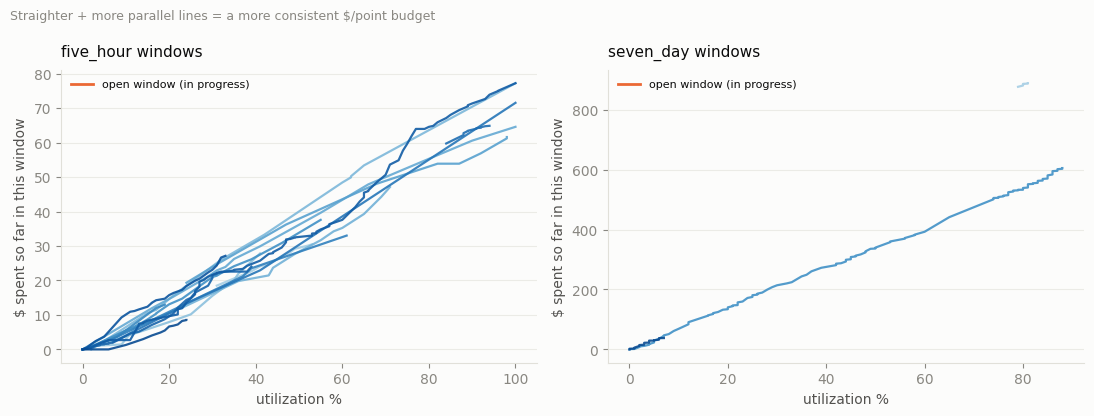

In [8]:
def window_trajectory(window, pct_col):
    ev = df_events[(df_events["ts"] >= window["start"]) & (df_events["ts"] < window["end"])].sort_values("ts")
    ev = ev.dropna(subset=["dollar_cost"]).assign(cum=lambda d: d["dollar_cost"].cumsum())
    polls = df_util[(df_util["ts"] >= window["start"]) & (df_util["ts"] <= window["end"])].sort_values("ts")
    polls = polls.dropna(subset=[pct_col])
    merged = pd.merge_asof(polls[["ts", pct_col]], ev[["ts", "cum"]], on="ts", direction="backward")
    merged["cum"] = merged["cum"].fillna(0.0)
    return merged


def plot_windows(ax, windows, pct_col, title):
    """One line per window, oldest -> newest as light -> dark blue
    (sequential encoding for a chronological sequence, not distinct
    categories - see the dataviz skill's color-formula reference)."""
    closed = [w for w in windows if not w["is_open"]]
    cmap = plt.get_cmap("Blues")
    for i, w in enumerate(closed):
        traj = window_trajectory(w, pct_col)
        if traj.empty:
            continue
        shade = 0.35 + 0.55 * (i / max(1, len(closed) - 1))
        ax.plot(traj[pct_col], traj["cum"], linewidth=1.6, color=cmap(shade), alpha=0.9)
    for w in windows:
        if not w["is_open"]:
            continue
        traj = window_trajectory(w, pct_col)
        if not traj.empty:
            ax.plot(traj[pct_col], traj["cum"], linewidth=2, color=ORANGE, label="open window (in progress)")
    ax.set_xlabel("utilization %")
    ax.set_ylabel("$ spent so far in this window")
    style_axes(ax, title)
    if any(w["is_open"] for w in windows):
        ax.legend(fontsize=8, frameon=False)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_windows(axes[0], fh_windows, "five_hour_pct", "five_hour windows")
plot_windows(axes[1], sd_windows, "seven_day_pct", "seven_day windows")
fig.suptitle("Straighter + more parallel lines = a more consistent $/point budget",
             x=0.01, ha="left", fontsize=9, color=INK_MUTED)
fig.tight_layout()
plt.show()


---
# Quantitative test

Everything above is descriptive. This is the actual measurement, and supersedes an earlier "the implied budget differs 40% between windows" reading that turned out to be an artefact of using cumulative totals instead of increments (see `AGENTS.md`'s Findings for the full post-mortem, kept there rather than re-derived here).

## Do the two meters move in fixed proportion?

Both meters watch the same usage stream. Whatever Anthropic's internal weighted-usage unit is, its ratio between two readings cancels that unit entirely: $\Delta_{5h}\% / \Delta_{7d}\% = B_{7d}/B_{5h}$, a constant *if and only if* neither budget is being throttled relative to the other. This needs no cost model at all - it's the strongest check available.

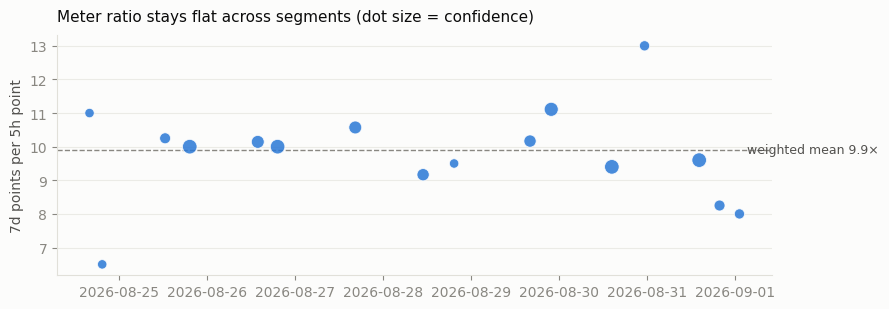

B_7d / B_5h = 9.92 -> one 7-day point is worth about 9.9 five-hour points, and that holds even in the segment that ran with the weekly meter at 79-81% (warning severity) - so the 5-hour allowance is NOT reduced when the weekly is nearly exhausted. That rules out weekly-throttling as the explanation for the earlier apparent between-window differences.


In [8]:
def meter_ratio_segments(df_util):
    """Maximal runs where both meters are non-decreasing (no reset) and
    the 5h meter hasn't saturated. Within such a run both meters observed
    the same usage, so their ratio is B_7d / B_5h."""
    df_p = df_util.dropna(subset=["five_hour_pct", "seven_day_pct"]).sort_values("ts")
    l_seg, l_cur = [], []
    for _, r in df_p.iterrows():
        if l_cur:
            prev = l_cur[-1]
            if (r["five_hour_pct"] < prev["five_hour_pct"]
                    or r["seven_day_pct"] < prev["seven_day_pct"]
                    or prev["five_hour_pct"] >= 100):
                l_seg.append(l_cur); l_cur = []
        l_cur.append(r)
    if l_cur:
        l_seg.append(l_cur)
    l_out = []
    for seg in l_seg:
        a, b = seg[0], seg[-1]
        d5, d7 = b["five_hour_pct"] - a["five_hour_pct"], b["seven_day_pct"] - a["seven_day_pct"]
        if d5 <= 0 or d7 <= 0:
            continue
        l_out.append({"from": a["ts"], "d_5h": d5, "d_7d": d7, "ratio": d5 / d7})
    return pd.DataFrame(l_out)


df_ratio = meter_ratio_segments(df_util)
# d_7d-weighted mean - a segment with a bigger 7-day move is far less
# quantisation-noisy (the 7d meter is only integer-precise).
ratio_w = (df_ratio["ratio"] * df_ratio["d_7d"]).sum() / df_ratio["d_7d"].sum()

fig, ax = plt.subplots(figsize=(9, 3.2))
size = 30 + 8 * df_ratio["d_7d"]   # bigger 7d move = bigger, more trustworthy dot
ax.scatter(df_ratio["from"], df_ratio["ratio"], s=size, color=BLUE, alpha=0.85,
           edgecolor="white", linewidth=0.6, zorder=3)
ax.axhline(ratio_w, color=INK_MUTED, linewidth=1, linestyle="--", zorder=1)
ax.text(df_ratio["from"].max(), ratio_w, f"  weighted mean {ratio_w:.1f}\u00d7",
        va="center", fontsize=9, color=INK_SECONDARY)
ax.set_ylabel("7d points per 5h point")
style_axes(ax, "Meter ratio stays flat across segments (dot size = confidence)")
fig.tight_layout()
plt.show()

print(f"B_7d / B_5h = {ratio_w:.2f} -> one 7-day point is worth about "
      f"{ratio_w:.1f} five-hour points, and that holds even in the segment "
      f"that ran with the weekly meter at 79-81% (warning severity) - so "
      f"the 5-hour allowance is NOT reduced when the weekly is nearly "
      f"exhausted. That rules out weekly-throttling as the explanation "
      f"for the earlier apparent between-window differences.")


## Which predictor actually explains the meter?

The fix for the cumulative-totals artefact above: regress on the **change between two consecutive polls**, not cumulative totals within a window (a cumulative reading shares almost all of its history with the reading before it - regressing on that gives a near-1 R² that means nothing, and lets a small meter-lag offset near a window's start propagate into every later ratio, which is exactly what produced the phantom between-window spread). Every predictor below is fit through the origin (no usage -> no utilization) on the same set of intervals.

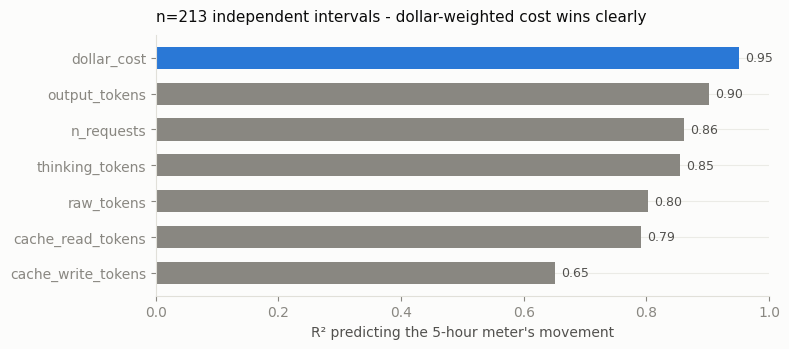

Raw tokens price a cache read the same as an output token - the data plainly rejects that. n_requests alone scores respectably too, but that's not independent: a bigger interval has both more requests and more dollars. Checked directly - adding a per-request term on top of $ cost improves R² by under 0.001, so there's no evidence of a meaningful fixed per-request charge; treat the meter as $-driven.
Reasoning effort can't be tested at all: 100% of this account's events are effort='high', so its coefficient is unidentifiable from this data.


In [9]:
def token_parts(usage):
    """thinking_tokens is a SUBSET of output_tokens - keep it separate so
    summing components below doesn't double-count it."""
    cc = usage.get("cache_creation") or {}
    think = (usage.get("output_tokens_details") or {}).get("thinking_tokens", 0)
    return pd.Series({
        "output_tokens": usage.get("output_tokens", 0), "thinking_tokens": think,
        "cache_read_tokens": usage.get("cache_read_input_tokens", 0),
        "cache_write_tokens": cc.get("ephemeral_5m_input_tokens", 0) + cc.get("ephemeral_1h_input_tokens", 0),
    })


df_events = df_events.join(df_events["usage"].apply(token_parts))
METRICS = ["dollar_cost", "raw_tokens", "output_tokens", "thinking_tokens",
           "cache_read_tokens", "cache_write_tokens"]


def build_increments(pct_col):
    """One row per consecutive poll pair where pct_col rose inside a single
    window (a drop means a reset; >=100 means saturated - usage stops being
    observable there)."""
    df_p = df_util.dropna(subset=[pct_col]).sort_values("ts").reset_index(drop=True)
    l_rows = []
    for i in range(len(df_p) - 1):
        a, b = df_p.iloc[i], df_p.iloc[i + 1]
        if b[pct_col] <= a[pct_col] or a[pct_col] >= 100:
            continue
        s_in = (df_events["ts"] >= a["ts"]) & (df_events["ts"] < b["ts"])
        if not s_in.sum():
            continue
        d_row = {"ts": a["ts"], "d_pct": b[pct_col] - a[pct_col], "n_requests": int(s_in.sum())}
        for m in METRICS:
            d_row[m] = df_events.loc[s_in, m].sum()
        l_rows.append(d_row)
    return pd.DataFrame(l_rows)


def fit_through_origin(x, y):
    slope = (x @ y) / (x @ x)
    return slope, 1 - ((y - slope * x) ** 2).sum() / ((y - y.mean()) ** 2).sum()


df_inc = build_increments("five_hour_pct")
r2_by_predictor = {}
for m in ["n_requests"] + METRICS:
    _, r2 = fit_through_origin(df_inc[m].to_numpy(float), df_inc["d_pct"].to_numpy(float))
    r2_by_predictor[m] = r2
s_r2 = pd.Series(r2_by_predictor).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [BLUE if p == "dollar_cost" else INK_MUTED for p in s_r2.index]
bars = ax.barh(s_r2.index, s_r2.values, color=colors, height=0.62)
for bar, v in zip(bars, s_r2.values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
            va="center", fontsize=9, color=INK_SECONDARY)
ax.set_xlim(0, 1)
ax.set_xlabel("R\u00b2 predicting the 5-hour meter's movement")
style_axes(ax, f"n={len(df_inc)} independent intervals - dollar-weighted cost wins clearly")
fig.tight_layout()
plt.show()

print("Raw tokens price a cache read the same as an output token - the data "
      "plainly rejects that. n_requests alone scores respectably too, but "
      "that's not independent: a bigger interval has both more requests and "
      "more dollars. Checked directly - adding a per-request term on top of "
      "$ cost improves R\u00b2 by under 0.001, so there's no evidence of a "
      "meaningful fixed per-request charge; treat the meter as $-driven.")
print("Reasoning effort can't be tested at all: 100% of this account's events "
      "are effort='high', so its coefficient is unidentifiable from this data.")


## What's the actual budget?

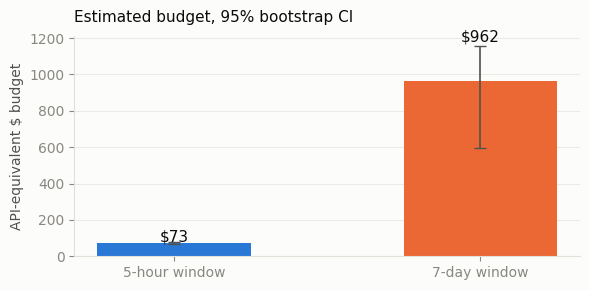

5-hour: n=213 R²=0.95  $72.81 [$66.93, $78.11]
7-day:  n=70 R²=0.65  $961.87 [$597.53, $1,154.21]
ratio from these two independent fits: 13.2x (vs 9.9x from the cost-model-free meter-ratio test above - prefer that one, the 7-day fit here has few intervals and coarse quantisation).


In [10]:
def budget_estimate(pct_col, n_boot=5000):
    """Full-scale budget = 100 / (pp per dollar), bootstrap CI over
    intervals - honest uncertainty given how few there are."""
    df_i = build_increments(pct_col)
    x, y = df_i["dollar_cost"].to_numpy(float), df_i["d_pct"].to_numpy(float)
    slope, r2 = fit_through_origin(x, y)
    rng = np.random.default_rng(0)
    a_idx = rng.integers(0, len(x), (n_boot, len(x)))
    a_boot = np.array([100 / ((x[i] @ y[i]) / (x[i] @ x[i])) for i in a_idx])
    lo, hi = np.percentile(a_boot, [2.5, 97.5])
    return {"n": len(x), "r2": r2, "budget": 100 / slope, "lo": lo, "hi": hi}


b_5h, b_7d = budget_estimate("five_hour_pct"), budget_estimate("seven_day_pct")

fig, ax = plt.subplots(figsize=(6, 3))
labels = ["5-hour window", "7-day window"]
vals = [b_5h["budget"], b_7d["budget"]]
errs = [[vals[i] - b["lo"] for i, b in enumerate([b_5h, b_7d])],
        [b["hi"] - vals[i] for i, b in enumerate([b_5h, b_7d])]]
ax.bar(labels, vals, yerr=errs, color=[BLUE, ORANGE], width=0.5,
       capsize=4, error_kw={"ecolor": INK_SECONDARY, "linewidth": 1.2})
for i, v in enumerate(vals):
    ax.text(i, v + errs[1][i] + vals[i] * 0.03, f"${v:,.0f}", ha="center",
            fontsize=11, color=INK, fontweight="medium")
ax.set_ylabel("API-equivalent $ budget")
style_axes(ax, "Estimated budget, 95% bootstrap CI")
fig.tight_layout()
plt.show()

print(f"5-hour: n={b_5h['n']} R\u00b2={b_5h['r2']:.2f}  ${b_5h['budget']:,.2f} "
      f"[${b_5h['lo']:,.2f}, ${b_5h['hi']:,.2f}]")
print(f"7-day:  n={b_7d['n']} R\u00b2={b_7d['r2']:.2f}  ${b_7d['budget']:,.2f} "
      f"[${b_7d['lo']:,.2f}, ${b_7d['hi']:,.2f}]")
print(f"ratio from these two independent fits: {b_7d['budget']/b_5h['budget']:.1f}x "
      f"(vs {ratio_w:.1f}x from the cost-model-free meter-ratio test above - "
      f"prefer that one, the 7-day fit here has few intervals and coarse "
      f"quantisation).")


## Where quota actually goes

Cost per token type (a compact table - six numbers, no chart needed), then a chart of where the account's quota has actually been spent across every logged event.

In [11]:
pp_per_dollar = 100 / b_5h["budget"]
rows = []
for label, mult in (("input", 1.0), ("output (incl. thinking)", 5.0),
                    ("cache write, 5-min", 1.25), ("cache write, 1-hour", 2.0),
                    ("cache read", 0.1)):
    price = PRICING["claude-sonnet-5"]["in"] * mult
    rows.append((label, price, (1 / pp_per_dollar) / price * 1e6))
df_table = pd.DataFrame(rows, columns=["token type", "$/MTok (Sonnet)", "tokens per 1pp (5h meter)"])
display(df_table.style.format({"$/MTok (Sonnet)": "${:.2g}", "tokens per 1pp (5h meter)": "{:,.0f}"}).hide(axis="index"))
print("Opus needs 2.5x fewer of each (same price ratio); Haiku needs 5x more.")


token type,$/MTok (Sonnet),tokens per 1pp (5h meter)
input,$2,"364,045"
output (incl. thinking),$10,"72,809"
"cache write, 5-min",$2.5,"291,236"
"cache write, 1-hour",$4,"182,023"
cache read,$0.2,"3,640,451"


Opus needs 2.5x fewer of each (same price ratio); Haiku needs 5x more.


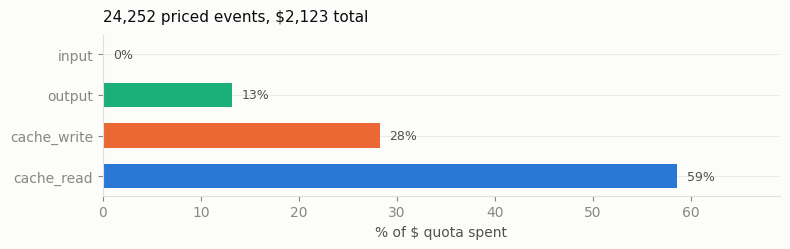

Cache reads dominate despite being the cheapest token type per-unit, simply because there are so many of them (Claude Code resends the full running conversation every turn). The direct, measured case for /clear and /compact.


In [12]:
def category_cost(usage, model):
    price = PRICING.get(model)
    if price is None:
        return None
    in_p, out_p = price["in"] / 1e6, price["out"] / 1e6
    cc = usage.get("cache_creation") or {}
    return pd.Series({
        "input": usage.get("input_tokens", 0) * in_p,
        "output": usage.get("output_tokens", 0) * out_p,
        "cache_read": usage.get("cache_read_input_tokens", 0) * in_p * CACHE_READ_MULT,
        "cache_write": (cc.get("ephemeral_5m_input_tokens", 0) * in_p * CACHE_WRITE_5M_MULT
                        + cc.get("ephemeral_1h_input_tokens", 0) * in_p * CACHE_WRITE_1H_MULT),
    })


df_cat = df_events.apply(lambda r: category_cost(r["usage"], r["model"]), axis=1).dropna()
s_cost = df_cat.sum().sort_values(ascending=False)
s_pct = 100 * s_cost / s_cost.sum()

fig, ax = plt.subplots(figsize=(8, 2.6))
cat_colors = {"cache_read": BLUE, "cache_write": ORANGE, "output": AQUA, "input": YELLOW}
bars = ax.barh(s_pct.index, s_pct.values, color=[cat_colors[c] for c in s_pct.index], height=0.6)
for bar, v in zip(bars, s_pct.values):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%", va="center",
            fontsize=9, color=INK_SECONDARY)
ax.set_xlim(0, max(s_pct.values) * 1.18)
ax.set_xlabel("% of $ quota spent")
style_axes(ax, f"{len(df_cat):,} priced events, ${s_cost.sum():,.0f} total")
fig.tight_layout()
plt.show()

print("Cache reads dominate despite being the cheapest token type per-unit, "
      "simply because there are so many of them (Claude Code resends the full "
      "running conversation every turn). The direct, measured case for "
      "/clear and /compact.")


## How predictable is a single reading?

The dollar-cost model gets R²=0.77-0.85 on single intervals - good, not perfect. Two candidate explanations for the residual were tested and both came back essentially negative (integer rounding of the reported percentage explains only a small fraction of it; adjacent-interval residuals show no meaningful negative autocorrelation, so it isn't timing misalignment either). What actually resolves it is aggregation:

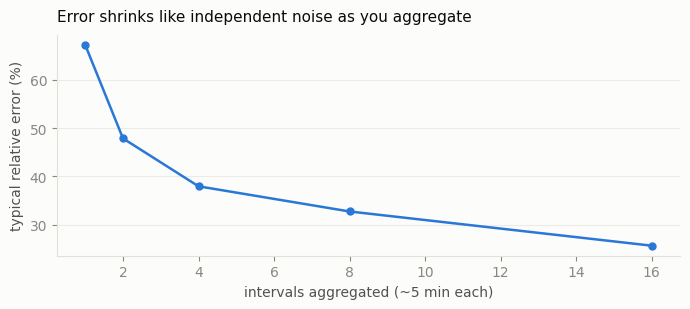

Good for predicting a session's worth of usage; not for a single turn. The remaining per-interval noise source isn't identified yet - sub-minute reporting lag and effort-level variation are untested candidates (the latter needs deliberately running some low/medium-effort sessions - this account has none).


In [14]:
x, y = df_inc["dollar_cost"].to_numpy(float), df_inc["d_pct"].to_numpy(float)
df_sorted = df_inc.sort_values("ts").reset_index(drop=True)
windows = (1, 2, 4, 8, 16)
rel_errs = []
for w in windows:
    xs = np.array([df_sorted["dollar_cost"].iloc[i:i + w].sum() for i in range(0, len(df_sorted) - w + 1, w)])
    ys = np.array([df_sorted["d_pct"].iloc[i:i + w].sum() for i in range(0, len(df_sorted) - w + 1, w)])
    s = (xs @ ys) / (xs @ xs)
    rel_errs.append(100 * np.sqrt((((ys - s * xs) / ys) ** 2).mean()))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(windows, rel_errs, marker="o", markersize=5, color=BLUE, linewidth=1.8)
ax.set_xlabel("intervals aggregated (~5 min each)")
ax.set_ylabel("typical relative error (%)")
style_axes(ax, "Error shrinks like independent noise as you aggregate")
fig.tight_layout()
plt.show()

print("Good for predicting a session's worth of usage; not for a single turn. "
      "The remaining per-interval noise source isn't identified yet - "
      "sub-minute reporting lag and effort-level variation are untested "
      "candidates (the latter needs deliberately running some low/medium-"
      "effort sessions - this account has none).")


## What this means

- **The budget does not vary.** The two meters stay in constant proportion across every segment, including one that ran with the weekly meter at 79-81%. The earlier "$58 in one window, $81 in another" reading was a per-window attribution offset in the (wrong) cumulative method, not a real change in allowance.
- **A 5-hour window is worth roughly the budget estimate above**, stable window to window - use the CI, not the point estimate.
- **A week is worth about the meter-ratio number × one 5-hour window**, so saturating every 5-hour window all week is not sustainable - the weekly cap binds first.
- **To sanity-check live**: watch the two meters early in a window - their ratio should land near the meter-ratio number, and local $ spent divided by 5-hour % should land near the budget estimate. A sustained departure means something has drifted, most likely usage from a client that writes no local transcript.

**Historical note on the weekly numbers**: Anthropic ran a +50% Claude Code weekly-limits promotion from 2026-05-13 through 2026-08-31 (5-hour limits were explicitly unaffected). Every `seven_day` reading in this dataset from before that date is measured under the inflated allowance - divide by 1.5 for the standard-allowance equivalent (the measured ~10.1× meter ratio then corresponds to a standard ~6.7×). Whether the ratio actually shifted when the promo lapsed hasn't been checked against the post-2026-09-01 data yet - a natural next step, not assumed here.

---
# Codex

`poll_codex.py` speaks the same JSON-RPC protocol Codex's own TUI statusline uses (`codex app-server --stdio`, no plain HTTP usage endpoint like Claude Code). Its two-tier shape maps directly onto Claude's: `primary` is a 300-minute (5-hour) window, `secondary` a 10,080-minute (7-day) window.

**Not built yet**: a dollar-cost regression like the Claude section's. Codex's local session files carry no token counts (confirmed empirically - 0 hits scanning for token/usage fields), so recomputing from local transcripts the way `analysis.ipynb` does for Claude doesn't work here. Codex's `account/usage/read` RPC reports real `estimatedUsageUsdMicros`/`estimatedUsageCreditsMicros` per thread when called with a `threadId` - a stronger test than Claude gets (a direct dollar figure, not an inferred model) - but needs `recompute_codex_events.py` actually wired into a cell here first. Below is just the raw trajectory so far.

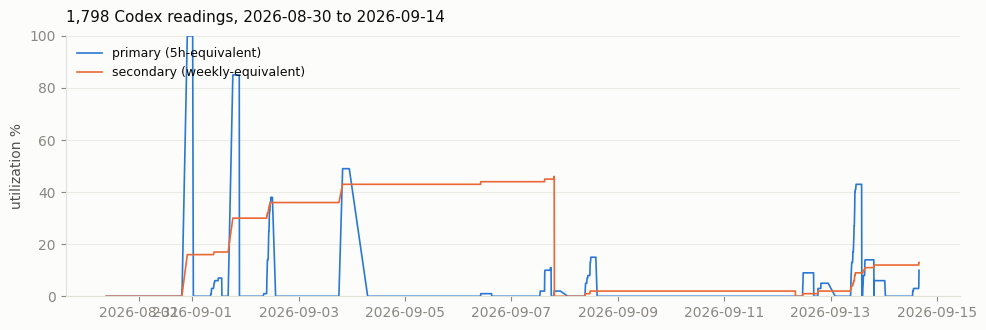

codex_primary: 1208 windows (1207 closed)
codex_secondary: 195 windows (194 closed)


In [15]:
df_codex = df_util[df_util["source"] == "codex_app_server"].dropna(subset=["codex_primary_pct"]).sort_values("ts")

if df_codex.empty:
    print("no Codex readings yet.")
else:
    fig, ax = plt.subplots(figsize=(10, 3.4))
    ax.plot(df_codex["ts"], df_codex["codex_primary_pct"], color=BLUE, linewidth=1.2, label="primary (5h-equivalent)")
    if "codex_secondary_pct" in df_codex:
        ax.plot(df_codex["ts"], df_codex["codex_secondary_pct"], color=ORANGE, linewidth=1.2, label="secondary (weekly-equivalent)")
    ax.set_ylabel("utilization %")
    ax.set_ylim(0, 100)
    style_axes(ax, f"{len(df_codex):,} Codex readings, {df_codex['ts'].min():%Y-%m-%d} to {df_codex['ts'].max():%Y-%m-%d}")
    ax.legend(fontsize=9, frameon=False, loc="upper left")
    fig.tight_layout()
    plt.show()

    codex_primary_windows = detect_windows(df_util, "codex_primary", pd.Timedelta(minutes=300))
    codex_secondary_windows = detect_windows(df_util, "codex_secondary", pd.Timedelta(minutes=10080))
    print(f"codex_primary: {len(codex_primary_windows)} windows "
          f"({sum(not w['is_open'] for w in codex_primary_windows)} closed)")
    print(f"codex_secondary: {len(codex_secondary_windows)} windows "
          f"({sum(not w['is_open'] for w in codex_secondary_windows)} closed)")
